In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
year_datas = []
for year in range(1997, 2007):
    yearly_data = pd.read_csv(f'./Plane Data/{year}.csv', encoding='latin-1', dtype={"CancellationCode": object})
    yearly_data = yearly_data[yearly_data['DepDelay'] > 0]
    yearly_data = yearly_data[yearly_data['ArrDelay'] > 0]
    yearly_data["TotalDelay"] = yearly_data['DepDelay'] + yearly_data['ArrDelay']
    yearly_data = yearly_data[["Year", "DayOfWeek", "CRSDepTime", "ArrDelay", "DepDelay", "TotalDelay"]]
    year_datas.append(yearly_data)

year_datas[0].head()

,Year,DayOfWeek,CRSDepTime,ArrDelay,DepDelay,TotalDelay
1,1997,3,1615,10.0,9.0,19.0
2,1997,4,1615,5.0,11.0,16.0
3,1997,5,1615,4.0,13.0,17.0
4,1997,2,1425,44.0,38.0,82.0
7,1997,5,1020,15.0,9.0,24.0


YEAR:  1997
Best day of the week to travel:  1
YEAR:  1998
Best day of the week to travel:  6
YEAR:  1999
Best day of the week to travel:  2
YEAR:  2000
Best day of the week to travel:  6
YEAR:  2001
Best day of the week to travel:  2
YEAR:  2002
Best day of the week to travel:  6
YEAR:  2003
Best day of the week to travel:  6
YEAR:  2004
Best day of the week to travel:  6
YEAR:  2005
Best day of the week to travel:  6
YEAR:  2006
Best day of the week to travel:  6


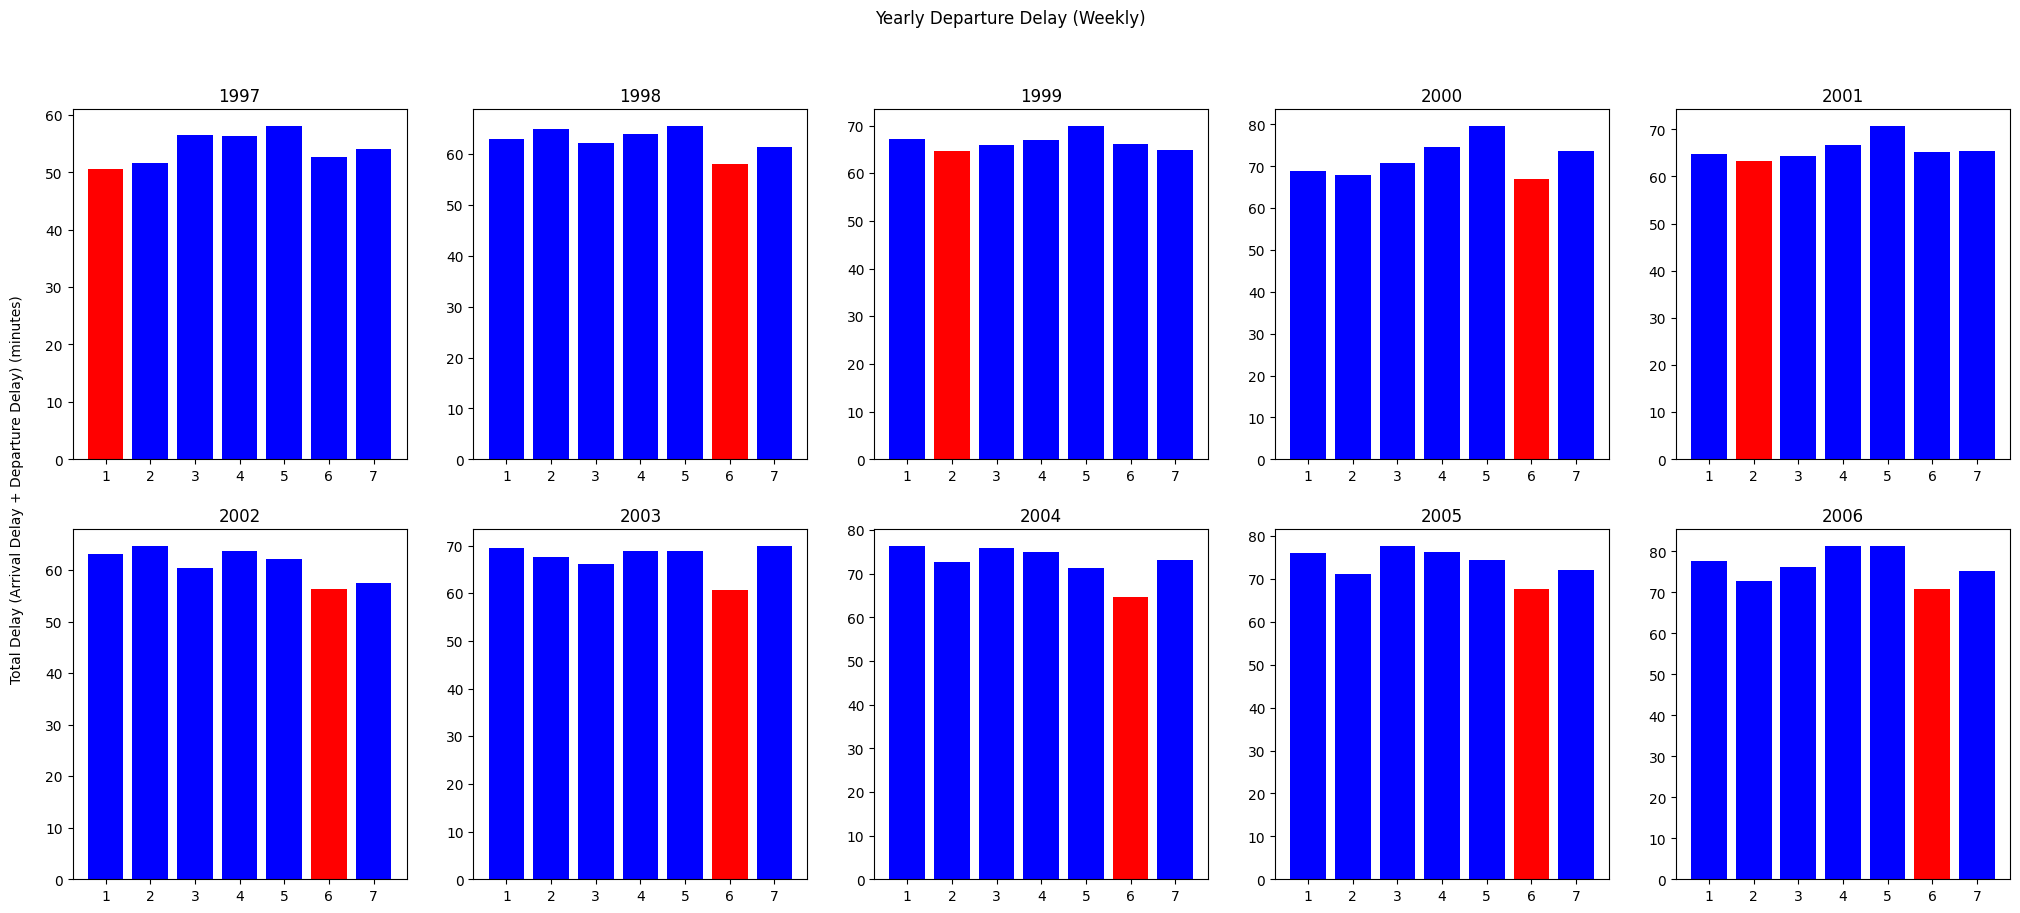

In [4]:
fig, axs = plt.subplots(2, 5, figsize=(25, 10))
fig.suptitle('Yearly Departure Delay (Weekly)')
fig.text(0.1, 0.5, 'Total Delay (Arrival Delay + Departure Delay) (minutes)', va='center', rotation='vertical')

for year_data in year_datas:
    current_year_data = year_data
    dayofweek = current_year_data.groupby('DayOfWeek')
    print("YEAR: ", current_year_data['Year'].iloc[0])
    means = dayofweek['TotalDelay'].mean()
    print("Best day of the week to travel: ", means.idxmin())
    plot_loc = int((current_year_data['Year'].iloc[0] - 1997) / 5), (current_year_data['Year'].iloc[0] - 1997) % 5
    axs[plot_loc].set_title(current_year_data['Year'].iloc[0])
    axs[plot_loc].bar(means.index, means, color=np.where(means.index == means.idxmin(), 'r', 'b'))



YEAR:  1997
Best hour to travel:  5
YEAR:  1998
Best hour to travel:  5
YEAR:  1999
Best hour to travel:  3
YEAR:  2000
Best hour to travel:  24
YEAR:  2001
Best hour to travel:  5
YEAR:  2002
Best hour to travel:  0
YEAR:  2003
Best hour to travel:  1
YEAR:  2004
Best hour to travel:  4
YEAR:  2005
Best hour to travel:  9
YEAR:  2006
Best hour to travel:  1


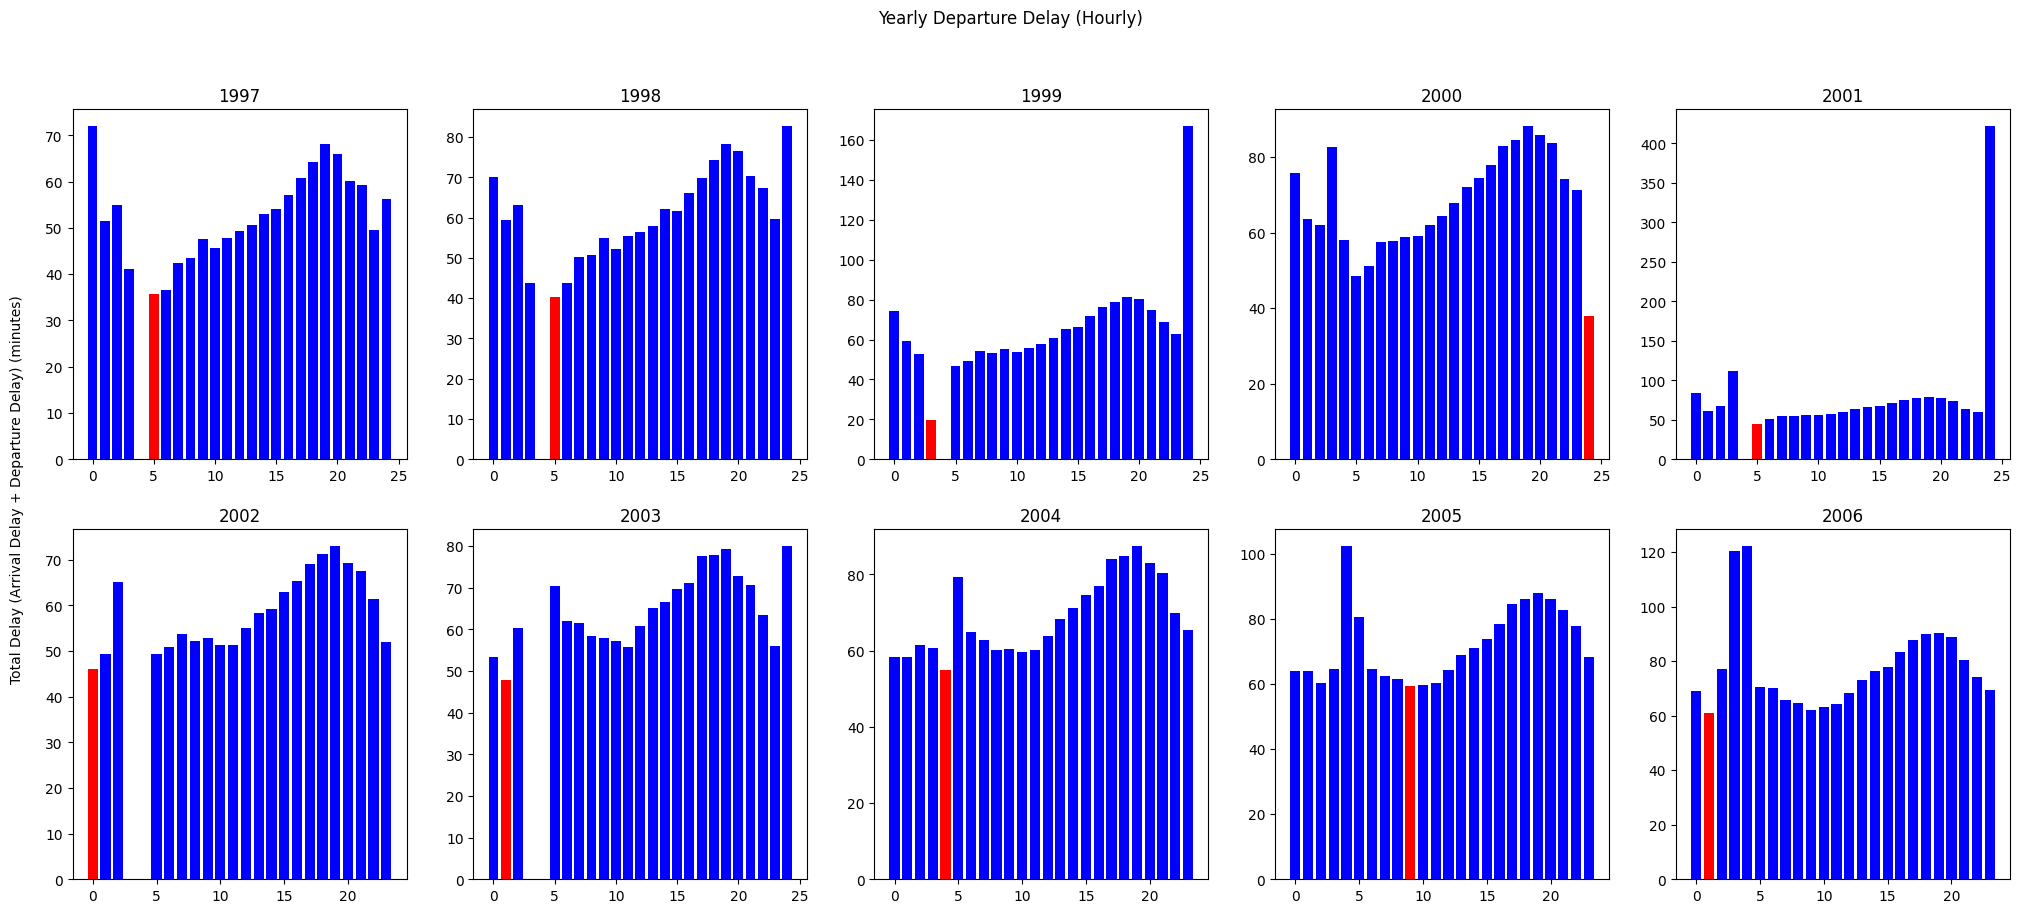

In [5]:
fig, axs = plt.subplots(2, 5, figsize=(25, 10))
fig.suptitle('Yearly Departure Delay (Hourly)')
fig.text(0.1, 0.5, 'Total Delay (Arrival Delay + Departure Delay) (minutes)', va='center', rotation='vertical')

for year_data in year_datas:
    current_year_data = year_data
    current_year_data["depTimeHour"] = current_year_data["CRSDepTime"] // 100
    hourly = current_year_data.groupby("depTimeHour")
    print("YEAR: ", current_year_data['Year'].iloc[0])
    means = hourly['TotalDelay'].mean()
    print("Best hour to travel: ", means.idxmin())
    plot_loc = int((current_year_data['Year'].iloc[0] - 1997) / 5), (current_year_data['Year'].iloc[0] - 1997) % 5
    axs[plot_loc].set_title(current_year_data['Year'].iloc[0])
    axs[plot_loc].bar(means.index, means, color=np.where(means.index == means.idxmin(), 'r', 'b'))
